In [1]:
import kagglehub
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset,TensorDataset
from torchvision import datasets, transforms
from torch.optim import Adam
import numpy as np

In [2]:
transform =transforms.Compose([
    transforms.ToTensor(),# transformo depois com transformers os dados em tensores
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])# faz uma normalização para que fique por exemplo em -1 a 1
])

In [3]:
train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)# carrego os dados de treino
test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)# carrego os dados de teste

print(len(train_data), len(test_data))
print(train_data[0][0].shape)  # confere o shape de uma imagem

50000 10000
torch.Size([3, 32, 32])


In [4]:
def get_model():# rede neural
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32,kernel_size=3),# features maps com 3 neuronios de entrada pois a imagem nao vem em array entao nao precisa 1 por pixel
        nn.MaxPool2d(kernel_size=2),# separa pela metade os features maps
        nn.ReLU(),# funcao dde ativacao para tirar os negativos e 0
        nn.Conv2d(in_channels=32, out_channels=10, kernel_size=3),
        nn.ReLU(),
        nn.Flatten(),# transforma em um vetor
        nn.Linear(1690,10)# saia com 10 classes
    )
    loss = nn.CrossEntropyLoss()# funcao de perda
    opt = Adam(model.parameters(), lr=0.001)# otimizador para aolicar a correcao dos pesos

    return model, loss, opt

In [5]:
def train(x,y,model,opt,loss):
    model.train()# treina o modelo
    opt.zero_grad()#zera o graiente
    prediction=model(x)# faz a prediição
    val_loss = loss(prediction.squeeze(),y.squeeze())# compara o modelo treinado com os labels certos para cada imagem
    val_loss.backward()# backpropagation calcula quantos deve ser ajustado os pesos da rede
    opt.step()#otimmizador aplica a correcao

    return val_loss.item()

In [6]:
train_dl = DataLoader(train_data, batch_size=32, shuffle=True)# separa em partes todo o treino e tambem embaralha eles
test_dl = DataLoader(test_data, batch_size=32, shuffle=False)# nao embaralha pois é somente validacao

In [7]:
model,loss,opt = get_model()# pega os objetos como a rede, a funcao de perda e o otimizador

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)   # move o modelo pra GPU

In [22]:
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()# coloca o modelo em modo de avaliacao
    predict = model(x)# faz a previsao
    max_values, max_indices = predict.max(-1)# mega o maior valor, ou seja a maior probabilidade de classe
    is_correct = max_indices == y# compara com o label certo
    return is_correct.cpu().numpy().tolist(), max_indices.cpu().numpy().tolist()

In [23]:
losses, accuracies_por_epoca = [], []

for epoch in range(100):# faz o loop de treino do moddelo
    epoch_losses=[]
    print(epoch)
    for ix,batch in enumerate(train_dl):
        x,y=batch #pega o valor ddo treino e tambem o seu respectivo label
        x, y = x.to(device), y.to(device)   # move os dados pra GP
        batch_loss =train(x,y,model,opt,loss)# retorna o valor do loss(quanto o modelo errou comparado ao label correto)
        epoch_losses.append(batch_loss)
    losses.append(np.mean(epoch_losses))
    epoch_accuracies = []
    for ix, batch in enumerate(train_dl):
        x, y = batch
        x, y = x.to(device), y.to(device)
        is_correct, preds = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    accuracies_por_epoca.append(np.mean(epoch_accuracies))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [24]:
accuracies = []
y_true = []
y_pred = []

for ix, batch in enumerate(test_dl):
    x, y = batch
    x, y = x.to(device), y.to(device)
    is_correct, preds = accuracy(x, y, model)  # agora recebe tambem a predicao (max_indices)
    accuracies.extend(is_correct)
    y_true.extend(y.cpu().numpy().tolist())    # guarda o label real de cada amostra
    y_pred.extend(preds)                        # guarda a predicao do modelo para cada amostra

test_accuracy = np.mean(accuracies)
print(test_accuracy*100)

63.019999999999996


In [25]:
classes = ('avião', 'carro', 'pássaro', 'gato', 'cervo','cachorro', 'sapo', 'cavalo', 'navio', 'caminhão')

In [26]:
import matplotlib.pyplot as plt

/tmp/ipykernel_8559/1490261860.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


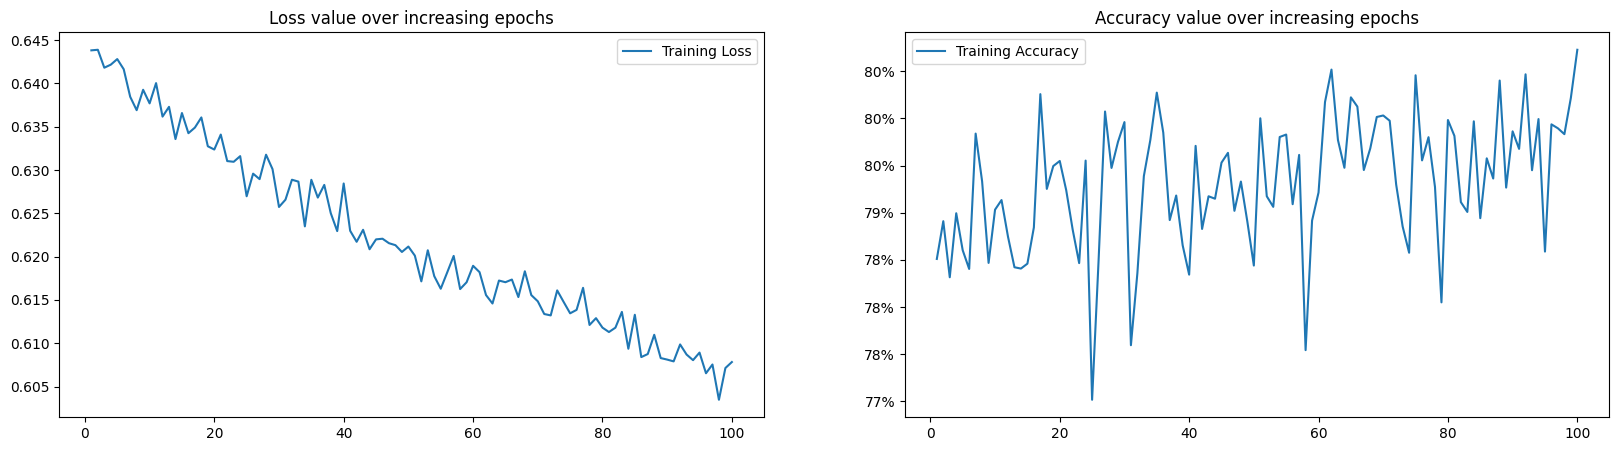

In [27]:
epochs = np.arange(100)+1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies_por_epoca, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()